# Healthcare Analytics for Doctor Visits

This notebook performs exploratory data analysis on the **Healthcare Analytics for Doctor Visits** dataset.

## Objectives
- Load and understand the healthcare dataset.
- Explore doctor visit patterns.
- Analyze the relationship between doctor visits, gender, illness, and chronic conditions.
- Create visualizations to communicate key insights.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Hp\\Desktop\\Advanced_Data_Sciecne-LAB\\Assignment_3\\1776250375-P2-Healthcare Analytics for Doctor Visits.csv')
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## Dataset Overview

In [2]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (5190, 13)

Column Names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [3]:
# Statistical summary
df.describe(include='all')

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
count,5190.000000,5190.000000,5190,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190,5190,5190,5190,5190
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no
freq,NaN,NaN,2702,NaN,NaN,NaN,NaN,NaN,2892,4968,4099,3098,4585
mean,2595.500000,0.301734,NaN,0.406385,0.583160,1.431985,0.861850,1.217534,NaN,NaN,NaN,NaN,NaN
std,1498.368279,0.798134,NaN,0.204782,0.368907,1.384152,2.887628,2.124266,NaN,NaN,NaN,NaN,NaN
min,1.000000,0.000000,NaN,0.190000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1298.250000,0.000000,NaN,0.220000,0.250000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,2595.500000,0.000000,NaN,0.320000,0.550000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,3892.750000,0.000000,NaN,0.620000,0.900000,2.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Remove unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("\nUpdated Dataset Shape:", df.shape)

Missing Values:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

Updated Dataset Shape: (5190, 12)


## Doctor Visits Analysis

In [5]:
print("Average Doctor Visits:", round(df['visits'].mean(), 2))
print("Median Doctor Visits:", df['visits'].median())
print("Maximum Doctor Visits:", df['visits'].max())
print("Minimum Doctor Visits:", df['visits'].min())

df['visits'].describe()

Average Doctor Visits: 0.3
Median Doctor Visits: 0.0
Maximum Doctor Visits: 9
Minimum Doctor Visits: 0


count    5190.000000
mean        0.301734
std         0.798134
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: visits, dtype: float64

## Analysis 1: Average Doctor Visits by Gender

gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


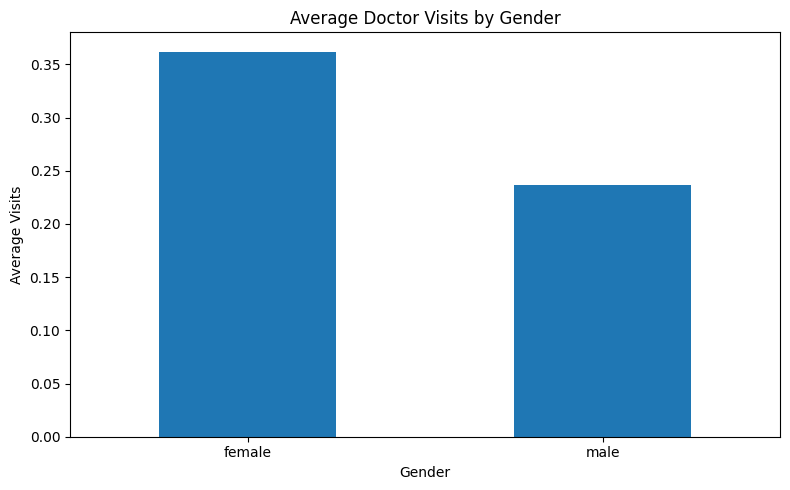

In [6]:
gender_visits = df.groupby('gender')['visits'].mean()
print(gender_visits)

plt.figure(figsize=(8, 5))
gender_visits.plot(kind='bar')
plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Visits')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Analysis 2: Doctor Visits by Chronic Condition

nchronic
no     0.272111
yes    0.345602
Name: visits, dtype: float64


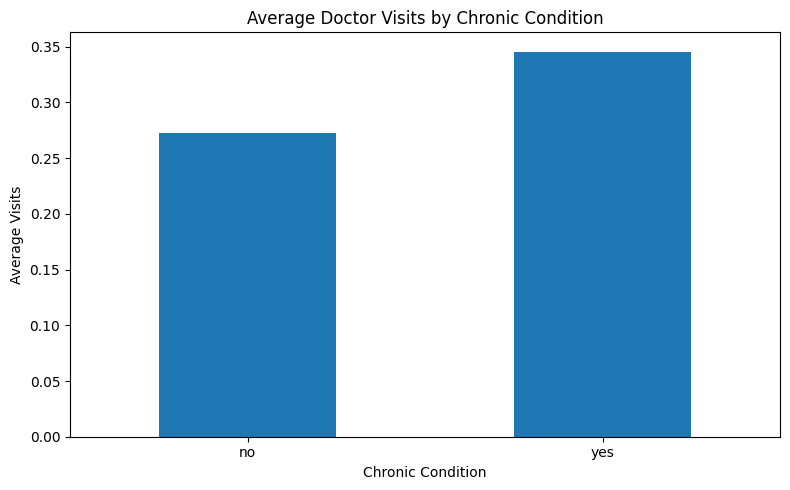

In [7]:
chronic_visits = df.groupby('nchronic')['visits'].mean()
print(chronic_visits)

plt.figure(figsize=(8, 5))
chronic_visits.reindex(['no', 'yes']).plot(kind='bar')
plt.title('Average Doctor Visits by Chronic Condition')
plt.xlabel('Chronic Condition')
plt.ylabel('Average Visits')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Analysis 3: Doctor Visits by Illness Level

illness
0    0.078507
1    0.295482
2    0.403805
3    0.420664
4    0.576642
5    0.813559
Name: visits, dtype: float64


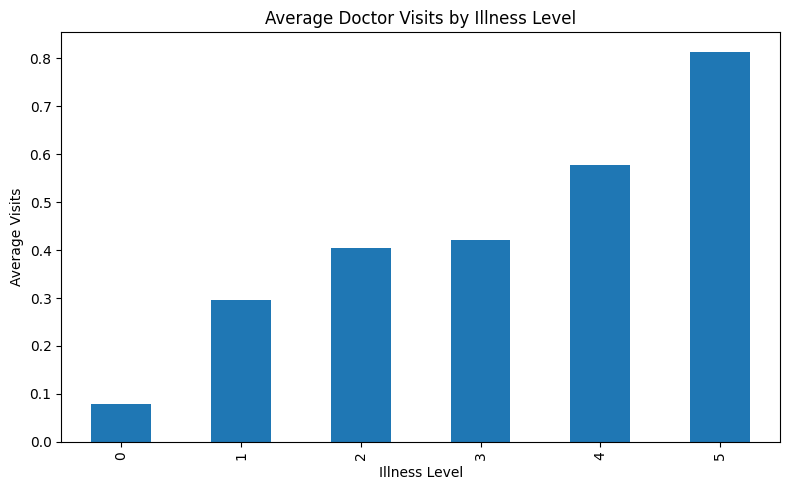

In [8]:
illness_visits = df.groupby('illness')['visits'].mean()
print(illness_visits)

plt.figure(figsize=(8, 5))
illness_visits.plot(kind='bar')
plt.title('Average Doctor Visits by Illness Level')
plt.xlabel('Illness Level')
plt.ylabel('Average Visits')
plt.tight_layout()
plt.show()

## Analysis 4: Distribution of Chronic Conditions

nchronic
no     3098
yes    2092
Name: count, dtype: int64


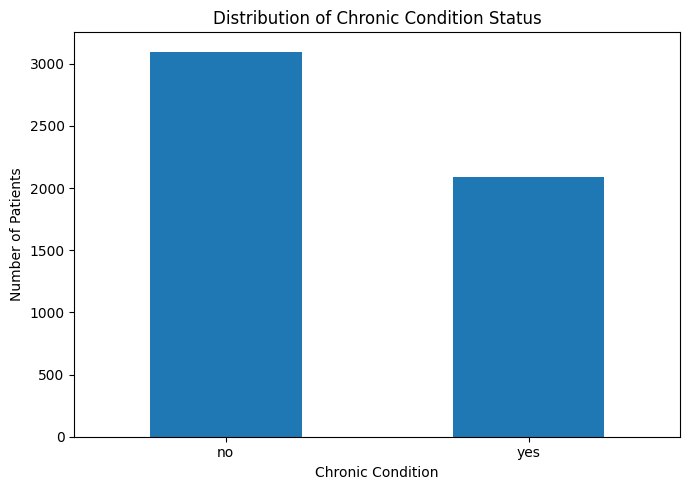

In [9]:
chronic_count = df['nchronic'].value_counts()
print(chronic_count)

plt.figure(figsize=(7, 5))
chronic_count.plot(kind='bar')
plt.title('Distribution of Chronic Condition Status')
plt.xlabel('Chronic Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()